# Imports

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset preparation

In [2]:
df = pd.read_csv('/kaggle/input/datasets/rayane1kahlaoui/bankdataset/bank.csv', sep=';')
df_full = pd.read_csv('/kaggle/input/datasets/rayane1kahlaoui/bank-full/bank-full.csv', sep=';')

le = LabelEncoder()
df['y'] = le.fit_transform(df['y'])        
df_full['y'] = le.fit_transform(df_full['y'])

cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols.remove('y')

cat_cols_full = df_full.select_dtypes(include='object').columns.tolist()
num_cols_full = df_full.select_dtypes(include=['int64','float64']).columns.tolist()
num_cols_full.remove('y')

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

preprocessor_full = ColumnTransformer([
    ('num', StandardScaler(), num_cols_full),
    ('cat', OneHotEncoder(drop='first'), cat_cols_full)
])

X = preprocessor.fit_transform(df.drop('y', axis=1))
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)


X_full = preprocessor_full.fit_transform(df_full.drop('y', axis=1))
y_full = df_full['y']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

results = []
results_pca = []

# KNN

In [3]:
knn_params = [3, 5, 7]
for k in knn_params:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_full, y_train_full)
    y_pred = knn.predict(X_test_full)
    y_prob = knn.predict_proba(X_test_full)[:,1]
    
    acc = accuracy_score(y_test_full, y_pred)
    prec = precision_score(y_test_full, y_pred)
    rec = recall_score(y_test_full, y_pred)
    f1 = f1_score(y_test_full, y_pred)
    auc = roc_auc_score(y_test_full, y_prob)
    
    results.append(['KNN', f'k={k}', acc, prec, rec, f1, auc])
    print(f"KNN (k={k}) => Acc: {acc:.3f}, F1: {f1:.3f}, AUC: {auc:.3f}")


KNN (k=3) => Acc: 0.893, F1: 0.452, AUC: 0.792
KNN (k=5) => Acc: 0.896, F1: 0.447, AUC: 0.837
KNN (k=7) => Acc: 0.896, F1: 0.417, AUC: 0.854


# SVM

In [4]:
svm_kernels = ['linear', 'rbf']
svm_C = [0.1, 1, 10]

for kernel in svm_kernels:
    for C in svm_C:
        svm = SVC(kernel=kernel, C=C, probability=True, class_weight='balanced', random_state=42)
        svm.fit(X_train_bal, y_train_bal)
        y_pred = svm.predict(X_test)
        y_prob = svm.predict_proba(X_test)[:,1]
        
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)
        
        results.append(['SVM', f'kernel={kernel},C={C}', acc, prec, rec, f1, auc])
        print(f"SVM (kernel={kernel}, C={C}) => Acc: {acc:.3f}, F1: {f1:.3f}, AUC: {auc:.3f}")


SVM (kernel=linear, C=0.1) => Acc: 0.818, F1: 0.498, AUC: 0.893
SVM (kernel=linear, C=1) => Acc: 0.815, F1: 0.495, AUC: 0.891
SVM (kernel=linear, C=10) => Acc: 0.817, F1: 0.497, AUC: 0.891
SVM (kernel=rbf, C=0.1) => Acc: 0.830, F1: 0.525, AUC: 0.894
SVM (kernel=rbf, C=1) => Acc: 0.846, F1: 0.519, AUC: 0.894
SVM (kernel=rbf, C=10) => Acc: 0.859, F1: 0.407, AUC: 0.879


# Random Forest

In [5]:
rf_trees = [50, 100, 200]
for n in rf_trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train_bal, y_train_bal)
    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:,1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append(['RandomForest', f'n_estimators={n}', acc, prec, rec, f1, auc])
    print(f"Random Forest ({n} trees) => Acc: {acc:.3f}, F1: {f1:.3f}, AUC: {auc:.3f}")

Random Forest (50 trees) => Acc: 0.877, F1: 0.373, AUC: 0.889
Random Forest (100 trees) => Acc: 0.877, F1: 0.387, AUC: 0.893
Random Forest (200 trees) => Acc: 0.883, F1: 0.404, AUC: 0.898


# Logistic Regression

In [6]:
log_C = [0.1, 1, 10]
log_max_iter = [100, 200]

for C in log_C:
    for max_iter in log_max_iter:
        logreg = LogisticRegression(C=C, max_iter=max_iter, solver='liblinear',
                                    class_weight='balanced', random_state=42)
        logreg.fit(X_train_bal, y_train_bal)
        y_pred = logreg.predict(X_test)
        y_prob = logreg.predict_proba(X_test)[:,1]
        
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)
        
        results.append(['LogisticRegression', f'C={C},max_iter={max_iter}', acc, prec, rec, f1, auc])
        print(f"LogReg (C={C}, max_iter={max_iter}) => Acc: {acc:.3f}, F1: {f1:.3f}, AUC: {auc:.3f}")

LogReg (C=0.1, max_iter=100) => Acc: 0.821, F1: 0.491, AUC: 0.892
LogReg (C=0.1, max_iter=200) => Acc: 0.821, F1: 0.491, AUC: 0.892
LogReg (C=1, max_iter=100) => Acc: 0.825, F1: 0.503, AUC: 0.891
LogReg (C=1, max_iter=200) => Acc: 0.825, F1: 0.503, AUC: 0.891
LogReg (C=10, max_iter=100) => Acc: 0.825, F1: 0.500, AUC: 0.890
LogReg (C=10, max_iter=200) => Acc: 0.825, F1: 0.500, AUC: 0.890


In [7]:
results_df = pd.DataFrame(results, columns=['Model','Params','Accuracy','Precision','Recall','F1','AUC'])
results_df = results_df.sort_values(by='F1', ascending=False).reset_index(drop=True)
results_df.head(10)

,Model,Params,Accuracy,Precision,Recall,F1,AUC
0,SVM,"kernel=rbf,C=0.1",0.829834,0.386364,0.817308,0.524691,0.893643
1,SVM,"kernel=rbf,C=1",0.846409,0.405405,0.721154,0.519031,0.894195
2,LogisticRegression,"C=1,max_iter=100",0.825414,0.373832,0.769231,0.503145,0.891074
3,LogisticRegression,"C=1,max_iter=200",0.825414,0.373832,0.769231,0.503145,0.891074
4,LogisticRegression,"C=10,max_iter=100",0.825414,0.372642,0.759615,0.500000,0.890197
5,LogisticRegression,"C=10,max_iter=200",0.825414,0.372642,0.759615,0.500000,0.890197
6,SVM,"kernel=linear,C=0.1",0.817680,0.364444,0.788462,0.498480,0.892508
7,SVM,"kernel=linear,C=10",0.816575,0.362832,0.788462,0.496970,0.890948
8,SVM,"kernel=linear,C=1",0.815470,0.361233,0.788462,0.495468,0.891266
9,LogisticRegression,"C=0.1,max_iter=100",0.820994,0.364486,0.750000,0.490566,0.892346


# Réduction de dimension

# PCA

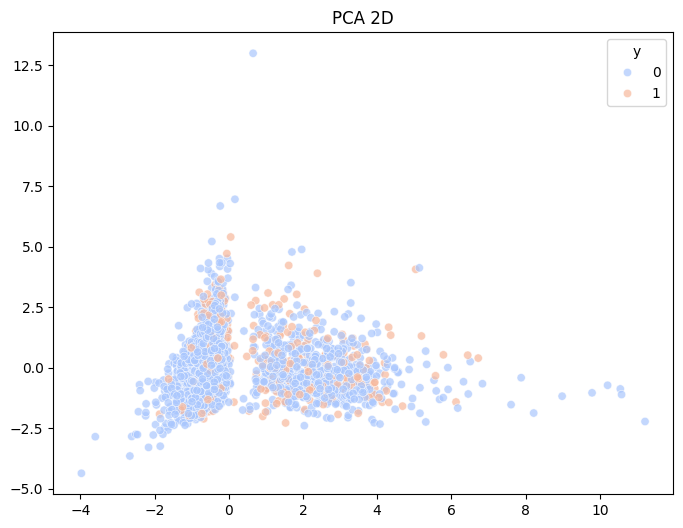

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray() if hasattr(X,"toarray") else X)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='coolwarm', alpha=0.7)
plt.title("PCA 2D")
plt.show()

# Split PCA train/test
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

# Évaluation après réduction de dimension

# Split PCA

In [9]:
# PCA 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray() if hasattr(X,"toarray") else X)

# Split train/test sur les données réduites
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

# KNN

In [10]:
for k in knn_params:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_pca, y_train_pca)
    y_pred = knn.predict(X_test_pca)
    y_prob = knn.predict_proba(X_test_pca)[:,1]
    
    acc = accuracy_score(y_test_pca, y_pred)
    prec = precision_score(y_test_pca, y_pred)
    rec = recall_score(y_test_pca, y_pred)
    f1 = f1_score(y_test_pca, y_pred)
    auc = roc_auc_score(y_test_pca, y_prob)
    
    results_pca.append(['KNN', f'k={k}', acc, prec, rec, f1, auc])
    print(f"KNN PCA (k={k}) => Acc: {acc:.3f}, F1: {f1:.3f}, AUC: {auc:.3f}")

KNN PCA (k=3) => Acc: 0.864, F1: 0.075, AUC: 0.556
KNN PCA (k=5) => Acc: 0.881, F1: 0.085, AUC: 0.587
KNN PCA (k=7) => Acc: 0.882, F1: 0.070, AUC: 0.590


# SVM

In [11]:
for kernel in svm_kernels:
    for C in svm_C:
        svm = SVC(kernel=kernel, C=C, probability=True, class_weight='balanced', random_state=42)
        svm.fit(X_train_pca, y_train_pca)
        y_pred = svm.predict(X_test_pca)
        y_prob = svm.predict_proba(X_test_pca)[:,1]
        
        acc = accuracy_score(y_test_pca, y_pred)
        prec = precision_score(y_test_pca, y_pred, zero_division=0)
        rec = recall_score(y_test_pca, y_pred, zero_division=0)
        f1 = f1_score(y_test_pca, y_pred, zero_division=0)
        auc = roc_auc_score(y_test_pca, y_prob)
        
        results_pca.append(['SVM', f'kernel={kernel},C={C}', acc, prec, rec, f1, auc])
        print(f"SVM PCA (kernel={kernel}, C={C}) => Acc: {acc:.3f}, F1: {f1:.3f}, AUC: {auc:.3f}")


SVM PCA (kernel=linear, C=0.1) => Acc: 0.789, F1: 0.268, AUC: 0.645
SVM PCA (kernel=linear, C=1) => Acc: 0.788, F1: 0.267, AUC: 0.647
SVM PCA (kernel=linear, C=10) => Acc: 0.788, F1: 0.267, AUC: 0.647
SVM PCA (kernel=rbf, C=0.1) => Acc: 0.764, F1: 0.305, AUC: 0.678
SVM PCA (kernel=rbf, C=1) => Acc: 0.736, F1: 0.291, AUC: 0.684
SVM PCA (kernel=rbf, C=10) => Acc: 0.736, F1: 0.278, AUC: 0.686


# Random forest

In [12]:
for n in rf_trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train_pca, y_train_pca)
    y_pred = rf.predict(X_test_pca)
    y_prob = rf.predict_proba(X_test_pca)[:,1]
    
    acc = accuracy_score(y_test_pca, y_pred)
    prec = precision_score(y_test_pca, y_pred)
    rec = recall_score(y_test_pca, y_pred)
    f1 = f1_score(y_test_pca, y_pred)
    auc = roc_auc_score(y_test_pca, y_prob)
    
    results_pca.append(['RandomForest', f'n_estimators={n}', acc, prec, rec, f1, auc])
    print(f"Random Forest PCA ({n} trees) => Acc: {acc:.3f}, F1: {f1:.3f}, AUC: {auc:.3f}")

Random Forest PCA (50 trees) => Acc: 0.867, F1: 0.091, AUC: 0.545
Random Forest PCA (100 trees) => Acc: 0.873, F1: 0.135, AUC: 0.552
Random Forest PCA (200 trees) => Acc: 0.874, F1: 0.123, AUC: 0.552


# Logistic Regression


In [13]:
for C in log_C:
    for max_iter in log_max_iter:
        logreg = LogisticRegression(C=C, max_iter=max_iter, solver='liblinear',
                                    class_weight='balanced', random_state=42)
        logreg.fit(X_train_pca, y_train_pca)
        y_pred = logreg.predict(X_test_pca)
        y_prob = logreg.predict_proba(X_test_pca)[:,1]
        
        acc = accuracy_score(y_test_pca, y_pred)
        prec = precision_score(y_test_pca, y_pred)
        rec = recall_score(y_test_pca, y_pred)
        f1 = f1_score(y_test_pca, y_pred)
        auc = roc_auc_score(y_test_pca, y_prob)
        
        results_pca.append(['LogisticRegression', f'C={C},max_iter={max_iter}', acc, prec, rec, f1, auc])
        print(f"LogReg PCA (C={C}, max_iter={max_iter}) => Acc: {acc:.3f}, F1: {f1:.3f}, AUC: {auc:.3f}")

LogReg PCA (C=0.1, max_iter=100) => Acc: 0.726, F1: 0.279, AUC: 0.638
LogReg PCA (C=0.1, max_iter=200) => Acc: 0.726, F1: 0.279, AUC: 0.638
LogReg PCA (C=1, max_iter=100) => Acc: 0.726, F1: 0.279, AUC: 0.638
LogReg PCA (C=1, max_iter=200) => Acc: 0.726, F1: 0.279, AUC: 0.638
LogReg PCA (C=10, max_iter=100) => Acc: 0.726, F1: 0.279, AUC: 0.638
LogReg PCA (C=10, max_iter=200) => Acc: 0.726, F1: 0.279, AUC: 0.638


In [14]:
results_pca_df = pd.DataFrame(results_pca, columns=['Model','Params','Accuracy','Precision','Recall','F1','AUC'])
results_pca_df = results_pca_df.sort_values(by='F1', ascending=False).reset_index(drop=True)
results_pca_df.head(10)

,Model,Params,Accuracy,Precision,Recall,F1,AUC
0,SVM,"kernel=rbf,C=0.1",0.763536,0.230392,0.451923,0.305195,0.677951
1,SVM,"kernel=rbf,C=1",0.735912,0.210300,0.471154,0.290801,0.684145
2,LogisticRegression,"C=1,max_iter=100",0.725967,0.200000,0.461538,0.279070,0.637640
3,LogisticRegression,"C=1,max_iter=200",0.725967,0.200000,0.461538,0.279070,0.637640
4,LogisticRegression,"C=10,max_iter=200",0.725967,0.200000,0.461538,0.279070,0.637640
5,LogisticRegression,"C=10,max_iter=100",0.725967,0.200000,0.461538,0.279070,0.637640
6,LogisticRegression,"C=0.1,max_iter=100",0.725967,0.200000,0.461538,0.279070,0.637772
7,LogisticRegression,"C=0.1,max_iter=200",0.725967,0.200000,0.461538,0.279070,0.637772
8,SVM,"kernel=rbf,C=10",0.735912,0.202643,0.442308,0.277946,0.686270
9,SVM,"kernel=linear,C=0.1",0.788950,0.222930,0.336538,0.268199,0.645155
